In [1]:
from google.colab import files

uploaded = files.upload()

Saving placement_predict_50k Dataset (1).csv to placement_predict_50k Dataset (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

sns.set_style("whitegrid")   # optional: gives cleaner-looking charts


In [4]:
df = pd.read_csv("placement_predict_50k Dataset (1).csv")

In [5]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,StudentID,Gender,City,CollegeTier,Stream,Specialisation,Hostel,HistoryOfBacklogs,SGPA_Sem1,SGPA_Sem2,...,Publications,AptitudeTestScore,SoftSkillsRating,CodingTestScore,MockInterviewScore,ExtraCurricular,CGPA_Tier,PlacementStatus,IsAnomaly,Salary Package
0,1,Male,Ahmedabad,Tier2,ECE,Networking,No,No,6.02,6.54,...,0,66.7,2.2,49.4,47.8,0,Low,0,0,0.00
1,2,Female,Mumbai,Tier2,ECE,DataScience,Yes,Yes,5.84,5.12,...,0,48.2,2.4,26.7,25.8,0,Low,0,0,0.00
2,3,Male,Kolkata,Tier2,IT,DataScience,Yes,No,4.91,5.29,...,0,73.8,2.8,67.7,41.5,0,Low,1,0,3.89
3,4,Male,Jaipur,Tier1,CS,AI,No,No,7.67,8.03,...,0,69.8,2.7,66.9,48.0,0,Mid,1,0,8.37
4,5,Male,Pune,Tier2,IT,DataScience,Yes,No,8.14,8.97,...,1,73.1,2.1,71.7,61.7,1,High,1,0,18.99


In [6]:
print("\nShape of dataset (rows, columns):", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values per column:")
print(df.isnull().sum())


Shape of dataset (rows, columns): (50000, 32)

Column names:
['StudentID', 'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation', 'Hostel', 'HistoryOfBacklogs', 'SGPA_Sem1', 'SGPA_Sem2', 'SGPA_Sem3', 'SGPA_Sem4', 'SGPA_Sem5', 'SGPA_Sem6', 'SGPA_Sem7', 'SGPA_Sem8', 'CGPA', 'AttendancePercent', 'Internships', 'Projects', 'Workshops', 'Certifications', 'Publications', 'AptitudeTestScore', 'SoftSkillsRating', 'CodingTestScore', 'MockInterviewScore', 'ExtraCurricular', 'CGPA_Tier', 'PlacementStatus', 'IsAnomaly', 'Salary Package']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 32 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   StudentID           50000 non-null  int64  
 1   Gender              50000 non-null  object 
 2   City                50000 non-null  object 
 3   CollegeTier         50000 non-null  object 
 4   Stream              

In [7]:
df['Placed_Flag'] = df['PlacementStatus'].apply(lambda x: 1 if x == 'Placed' else 0)

In [8]:
num_cols = ['CGPA', 'AttendancePercent', 'AptitudeTestScore',
            'CodingTestScore', 'SoftSkillsRating', 'Salary Package']


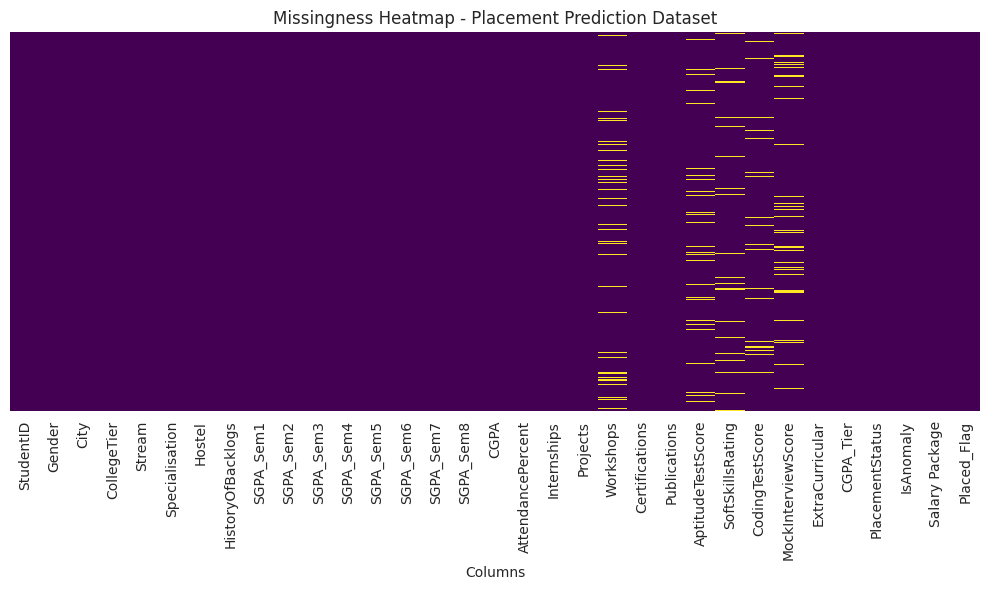

In [9]:
fig1 = plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Missingness Heatmap - Placement Prediction Dataset")
plt.xlabel("Columns")
plt.tight_layout()
plt.show()


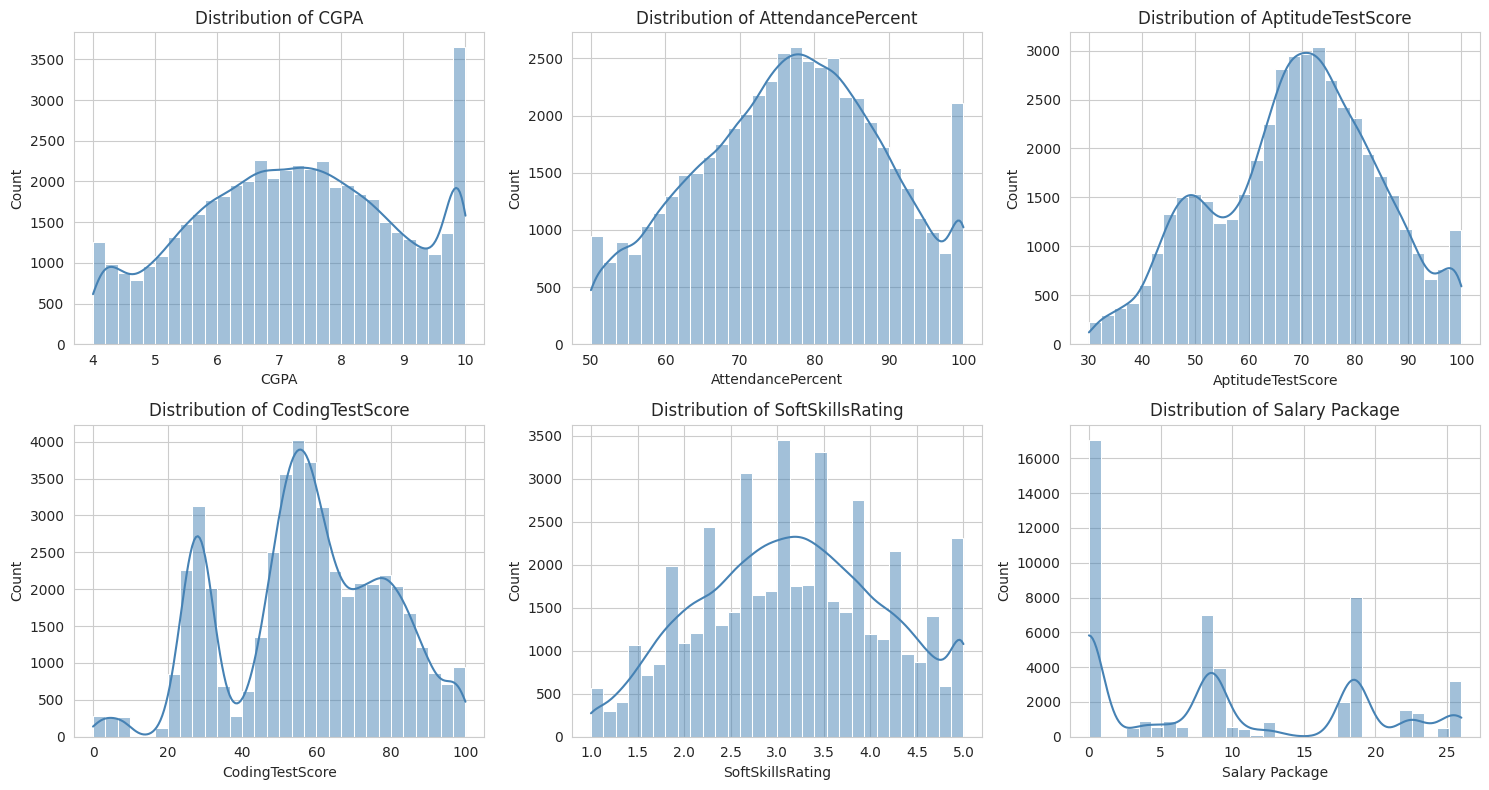

In [10]:
fig2, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.histplot(df[col].dropna(), bins=30, kde=True,
                 ax=axes[row, colpos], color='steelblue')
    axes[row, colpos].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_626/2158546150.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')


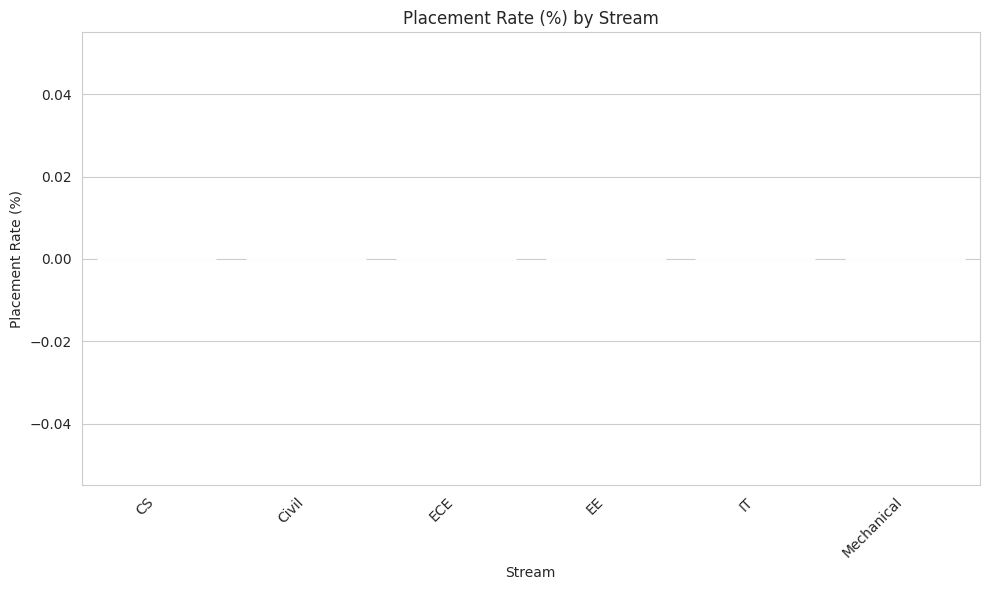


Placement rate (%) by stream:
Stream
CS            0.0
Civil         0.0
ECE           0.0
EE            0.0
IT            0.0
Mechanical    0.0
Name: Placed_Flag, dtype: float64


In [11]:
fig3 = plt.figure(figsize=(10, 6))

placement_rate = (
    df.groupby('Stream')['Placed_Flag'].mean().sort_values(ascending=False) * 100
)

sns.barplot(x=placement_rate.index, y=placement_rate.values, palette='crest')
plt.title('Placement Rate (%) by Stream')
plt.xlabel('Stream')
plt.ylabel('Placement Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nPlacement rate (%) by stream:")
print(placement_rate.round(2))


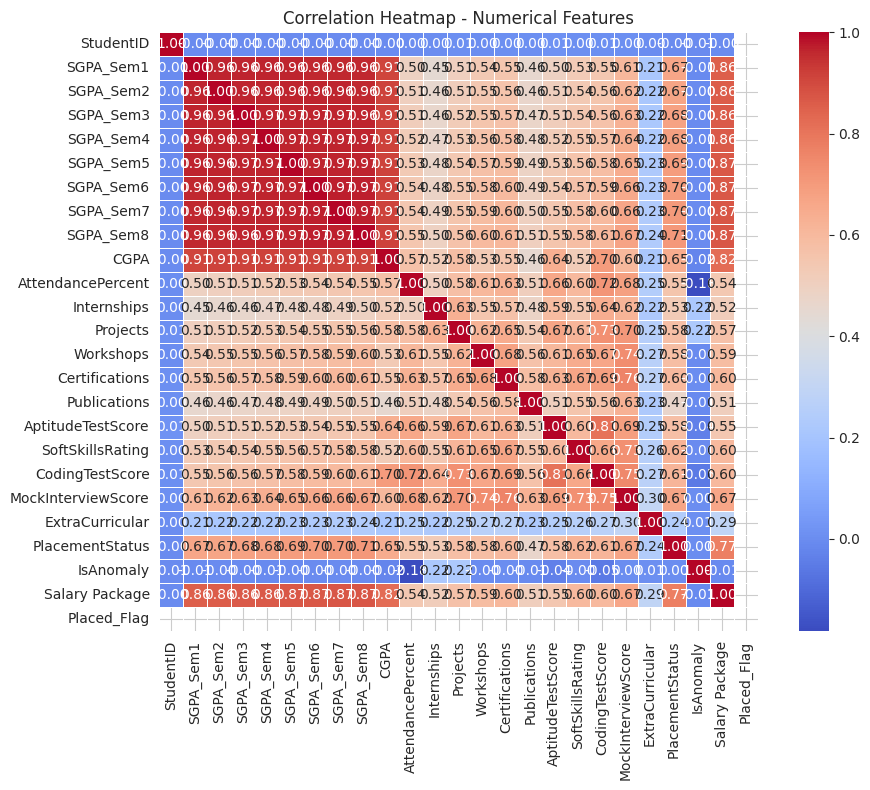

In [12]:
fig4 = plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap - Numerical Features')
plt.tight_layout()
plt.show()




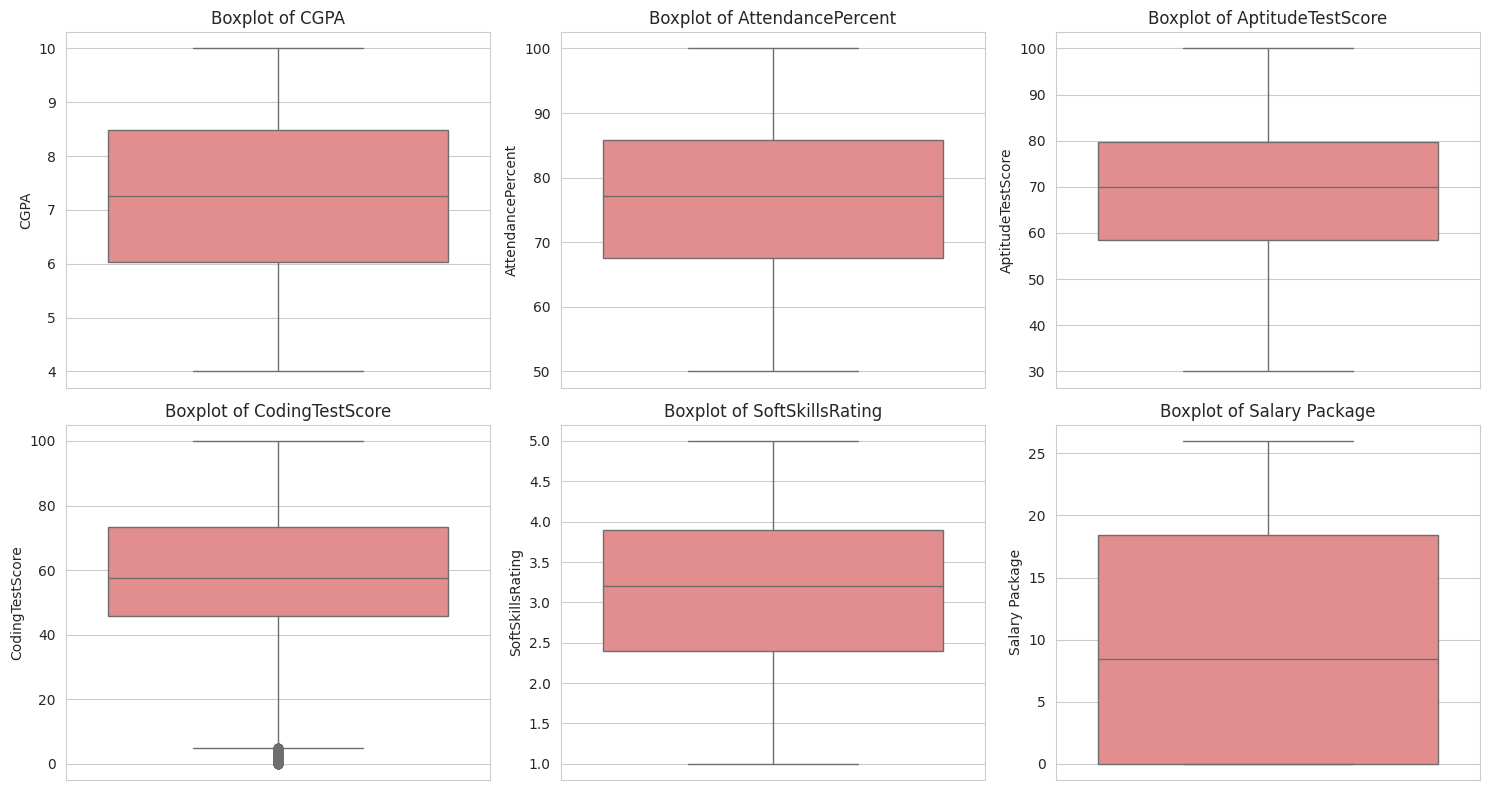

In [13]:
fig5, axes5 = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    row, colpos = divmod(i, 3)
    sns.boxplot(y=df[col], ax=axes5[row, colpos], color='lightcoral')
    axes5[row, colpos].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


In [15]:
pdf = PdfPages('EDA_Report.pdf')

pdf.savefig(fig1)   # Page 1: Missingness Heatmap
pdf.savefig(fig2)   # Page 2: Six Histograms
pdf.savefig(fig3)   # Page 3: Placement Rate by Stream
pdf.savefig(fig4)   # Page 4: Correlation Heatmap
pdf.savefig(fig5)   # Page 5: Boxplots

pdf.close()

print("\nEDA_Report.pdf created successfully with 5 pages!")




EDA_Report.pdf created successfully with 5 pages!


In [17]:
files.download('EDA_Report.pdf')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>